# Compute a covariance analogous to DES Y3

A *covariance matrix* $C_{ij}$ describes the joint scatter of measured two-point
functions: its diagonal holds their variances, its off-diagonal entries how pairs
of measurements scatter together. This notebook computes one for the DES Y3
3×2pt layout: the five redMaGiC lens and four source bins of
`des_y3_real.dataset`, with its baseline 3×2pt mask. The catalog densities and
per-component shape dispersions (the scatter of one ellipticity component of the
source galaxies) come from the project *adapter*
[covariance/des_y3_covariance.py](covariance/des_y3_covariance.py), the small
module that holds this survey's numbers.

This notebook computes Gaussian (G), super-sample (SSC), connected non-Gaussian
(cNG), and total covariance separately. It then reads the project's supplied
matrix and applies **the same likelihood mask** to both. The comparison concerns
analogous measurements; it is not a reproduction of the supplied covariance.
**The published DES Y3 covariance, `data/des_y3_cov_unblinded_final.txt`, remains
the covariance of every DES Y3 likelihood in this project.** The matrix computed
here matches only its layout and serves comparison: no likelihood data file is
overwritten, and the compiled likelihood never receives the computed matrix.

| Measurement choice | Value |
| --- | --- |
| Dataset | [data/des_y3_real.dataset](data/des_y3_real.dataset) |
| Lens / source bins | 5 / 4 |
| Bins per two-point observable | 20, 2.5–250 arcmin |
| Generated entries before cuts | 900 |
| Entries after the selected likelihood mask | 533 |

The forecast uses massless neutrinos, linear galaxy bias, zero magnification,
zero redshift-space distortions (RSD, the apparent radial displacement of
galaxies by their peculiar velocities) and a spherical-cap footprint: the survey
area is modeled as one circular patch of sky.

Gaussian galaxy–galaxy and galaxy–shear spectra include non-Limber
corrections; shear–shear remains Limber. The Limber approximation evaluates the
matter power at $k=(\ell+1/2)/\chi$ along the line of sight; it loses accuracy
at low multipoles and for narrow redshift bins. Gaussian intrinsic alignment
(IA, the correlation of galaxy shapes with the tidal field) in the NLA or TATT
model is optional below.

SSC/cNG retain their zero-IA Limber model. SSC uses the isotropic halo
response and cNG the halo trispectrum. Massive-neutrino non-Gaussian terms
are not implemented.

These physical choices differ from the supplied likelihood matrices.
Matching their measurement layout does not establish physical or numerical
equivalence.



The [covariance guide](covariance/README.md) explains survey inputs and how to
start Jupyter. The decomposition follows
[Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and
[Takada & Hu](https://arxiv.org/abs/1302.6994).
Covariance generation is excluded from the default build. Follow the
[project build steps](README.md#computing_covariances): after activating
Cocoa, unset `IGNORE_COSMOLIKE_DES_Y3_COVARIANCE` and recompile
this project. Restart the notebook kernel after rebuilding.

In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/des_y3"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_des_y3_interface as ci
import des_y3_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.likelihood import (
    read_likelihood_covariance,
    select_likelihood_entries,
)
from cosmolike_notebook_utils.covariance.forecast import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

## Choose the measurement and numerical settings

The default run computes the project's native measurement, the real-space
correlation functions of the DES Y3 data vector, once at boost 1. Set
`boosts = [1, 2]` to add the numerical comparison below.
`spaces = ["real", "fourier"]` also computes Fourier-space bandpowers; that
companion space is illustrative and is not compared to the supplied matrix.

`accuracy_boost` multiplies the internal interpolation refinements and
multipole cutoffs in [covariance/default.yaml](covariance/default.yaml).
The default power tables have 11,993 wavenumber samples; boost 2 uses
23,985 while retaining all original nodes. The loop below reinitializes
these tables for each boost. `integration_accuracy` independently selects the
quadrature rule, the points and weights that evaluate each integral: 96, 128,
256, 512 or 1,024 precomputed Gauss–Legendre points of the GNU Scientific
Library (GSL) per panel, an integration sub-interval, at levels 0–4.
Keep the scientific bins, cosmology and CAMB inputs fixed when refining.

The defaults remain **candidate accuracy settings**. A matrix is *positive
definite* when every linear combination of measurements has positive variance.
Positive definiteness and a small change in diagonal errors do not establish
convergence of all covariance modes or of Fisher parameter errors, the errors
forecast from the covariance and the derivatives of the data vector. A
comparison with the supplied matrix also mixes physical choices with numerical
differences.

The `gaussian` mapping selects the Gaussian spectra separately from numerical
accuracy. Use `ia="NLA", A1=0.6` for an illustrative constant NLA amplitude,
or `ia="TATT", A1=0.6, A2=0.2, B_TA=0.5` for TATT. A list gives one amplitude
per source bin. TATT B modes enter real-space shear covariance. These choices
change the Gaussian part only: SSC and cNG keep zero IA and the Limber
approximation, including the spectra of the SSC correction for measuring galaxy
density relative to its survey mean.

In [2]:
boosts = [1]
spaces = ['real']
gaussian = {"nonlimber": True, "ia": "none"}
settings = survey.configuration(
    accuracy_boost=boosts[0], gaussian=gaussian,
)
dataset = project/"data/des_y3_real.dataset"

# These are physical assumptions, not inferred from normalized n(z) columns.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
    "gaussian",
):
    print(key, settings[key])

camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)


def progress(stage, elapsed):
    """Report completed stages of this calculation, in seconds."""
    print(f"{elapsed:8.2f} s  {stage}")

area_deg2 4143.0
lens_density_arcmin2 [0.02206991865140178, 0.03811556894595951, 0.05828770119609519, 0.02945872243588231, 0.02514319207202297]
source_density_arcmin2 [1.475584985490327, 1.479383426887689, 1.483671693529899, 1.461247850098986]
sigma_e_component [0.2435002682964671, 0.2621945854120855, 0.2588927276307921, 0.3096827008528927]
bias [1.7, 1.7, 1.7, 2.0, 2.0]
cosmology {'omegam': 0.3, 'omegab': 0.05, 'H0': 70.0, 'ns': 0.965, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}
gaussian {

## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. Its four density factors can live in one,
two, three or four halos. The halo model, which describes all matter as residing
in gravitationally bound clumps called halos, separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.

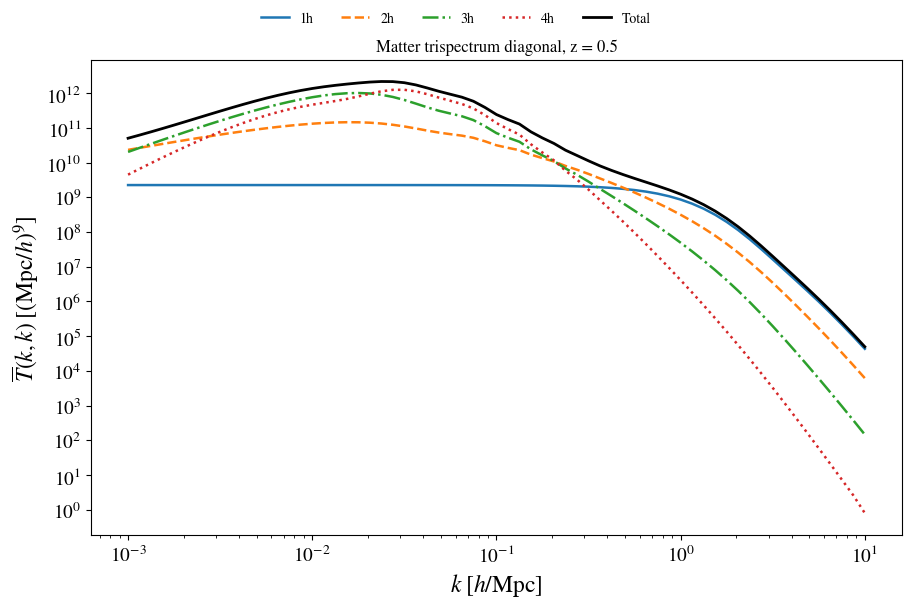

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute G, SSC, cNG and their sum

G describes covariance made from pairs of two-point spectra, including
catalog shot noise, from the finite number of lens galaxies, and shape noise,
from the random intrinsic ellipticities of source galaxies. SSC couples
measurements through a background density fluctuation larger than the
footprint. cNG is the remaining connected four-point contribution in the
adopted halo model.

Angular bins are consecutive within each observable. The Fourier companion
uses one E-mode row per source pair (the E mode is the curl-free part of the
shear pattern, the part lensing produces), with integer multipoles weighted by
$2\ell+1$ inside each band. This project has no Fourier-space likelihood, so
these bandpowers are an illustrative companion measurement, with no supplied
matrix to compare against.

Each computation retains internal cross-bin spectra even when the corresponding
observable is absent from the measured vector. The loop below changes only
numerical resolution, and stores all physical components at each requested boost.

In [4]:
# Each space uses its own projection. Changing the boost refines tables
# while preserving cosmology, observable ordering and measured bins.
results = {}
for space in spaces:
    if space not in ['real', 'fourier']:
        raise ValueError("Choose a measurement space supported by this adapter")
    results[space] = {}
    for boost in boosts:
        refined = dict(settings)
        refined.update(cov.covariance_accuracy(
            accuracy_boost=boost, **settings["accuracy_parameters"],
        ))
        # Reinstall the power tables at this boost, so their k grid
        # is refined along with the covariance integration tables.
        camb_tables = survey.initialize(interface=ci, settings=refined)
        ci.set_omp_threads(n=8)
        print(space, "accuracy boost", boost)
        results[space][boost] = survey.compute(
            interface=ci, settings=refined, space=space, progress=progress,
        )

native_space = 'real'
forecast = results[native_space][boosts[-1]]
print("Full covariance shape:", forecast["total"].shape)

real accuracy boost 1


    1.81 s  all_pairs_gaussian_spectra


    2.23 s  angular_and_mask_geometry


    3.57 s  gaussian_blocks
    3.73 s  observable_signal


    4.34 s  Matter shell 1/672


...

  146.71 s  Matter shell 577/672


  154.54 s  Matter shell 609/672


  162.33 s  Matter shell 641/672


  169.84 s  shared_halo_response_and_trispectrum
  170.04 s  ssc_and_connected_projection


  170.05 s  total
Full covariance shape: (900, 900)


## Apply the project's likelihood cuts

The supplied mask selects measurements, so the same selection must act on
both axes of G, SSC, cNG and their sum. The saved `indices` preserve the original
file positions after compaction, the removal of masked rows and columns. Probe
labels refer to contiguous groups in the uncut likelihood vector, including any
measured-pair exclusions.

The DES Y3 file lists every entry as a line `i j C_ij` holding the total only,
so only totals can be compared. The reader never splits a total into G, SSC and
cNG; for CosmoCov files whose Gaussian and non-Gaussian parts sit in separate
columns, it adds the two.

In the split-triangle figure, index 0 sits at the bottom left, so the newly
computed total fills the triangle *above* the drawn diagonal (the matrix's lower
triangle, row > column) and the supplied total fills the triangle *below* it;
the title's "Lower" and "Upper" name matrix triangles, not screen positions.
Each uses its own diagonal for correlation normalization; differences here are
**not** a numerical convergence test.

Supplied file size: 900
Retained comparison size: 533
Mask: 3x2pt_baseline.mask


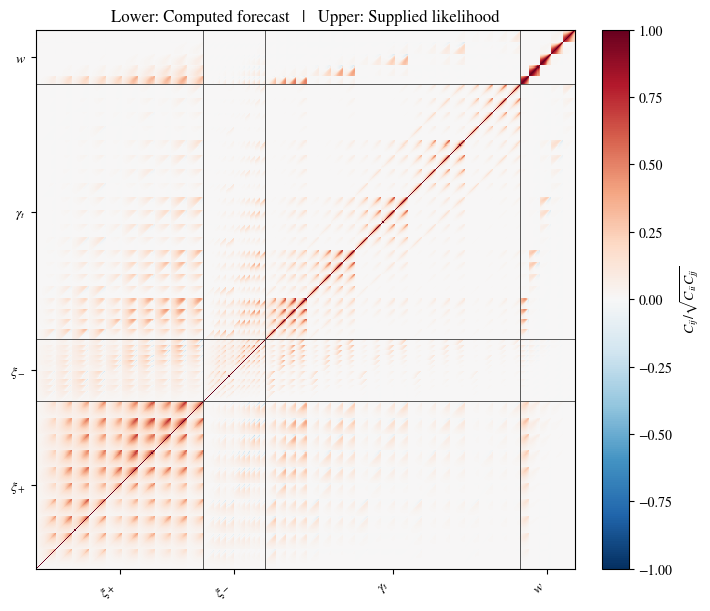

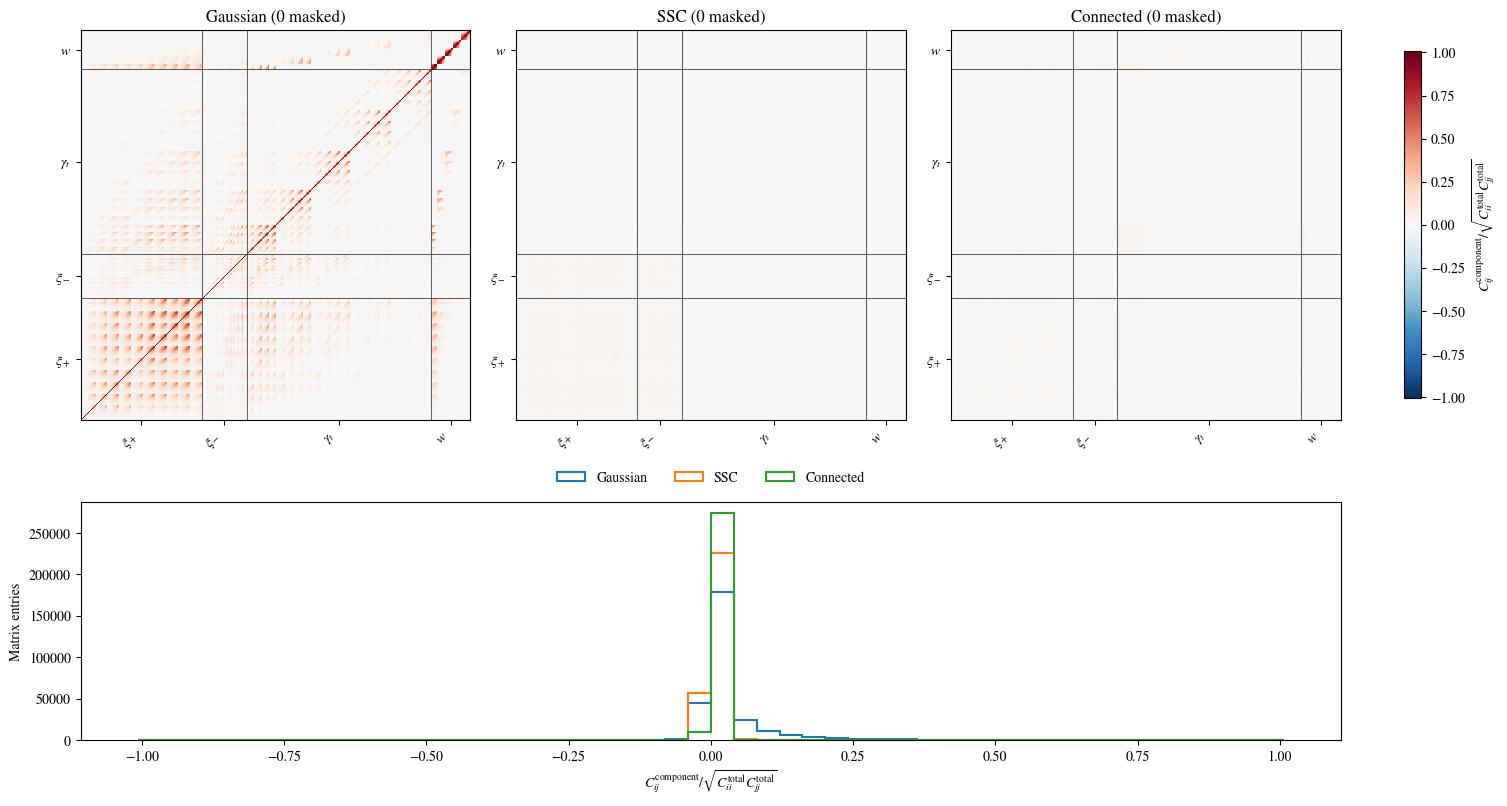

total positive definite: True minimum correlation eigenvalue: 0.019197335303358737
supplied positive definite: True minimum correlation eigenvalue: 0.02507904567128507


In [5]:
supplied = read_likelihood_covariance(dataset=dataset)
block_sizes = [200, 200, 400, 100]
block_labels = ['$\\xi_+$', '$\\xi_-$', '$\\gamma_t$', '$w$']
selected = select_likelihood_entries(
    forecast=forecast,
    supplied=supplied,
    block_sizes=block_sizes,
    block_labels=block_labels,
)
print("Supplied file size:", supplied["file_size"])
print("Retained comparison size:", len(selected["indices"]))
print("Mask:", Path(supplied["mask_file"]).name)

pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["supplied"],
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    labels=("Computed forecast", "Supplied likelihood"),
)
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="diagonal",
)

for label in ("total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    print(label, "positive definite:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

## Read the eigenvalue diagnostics

A covariance is *positive definite* when $v^{\mathsf T}Cv>0$ for every nonzero
vector $v$: every linear combination of measurements has positive variance.
Only then does the inverse $C^{-1}$ that enters $\chi^2$ exist.
`cov.covariance_modes` decides this from the eigenvalues of the correlation
matrix $R_{ij}=C_{ij}/\sqrt{C_{ii}C_{jj}}$. Dividing each measurement by its
standard deviation changes units but not the sign of any mode, and it keeps the
very different variances of shear and clustering from burying the smallest
eigenvalues in rounding error. The raw eigenvalues are returned as well.

The next cell applies it to every component after the likelihood cuts. G
includes noise and should be positive definite on its own. SSC adds, with
positive weights, the outer product of one response vector per radial
integration node; neighboring nodes respond almost alike, so most SSC
eigenvalues are zero up to rounding and some print slightly negative: SSC is
positive semidefinite, not definite. cNG need not be positive alone; even single
variances can be negative, and then no correlation eigenvalues exist. The total
must be positive definite. The *condition number*, largest over smallest
eigenvalue of $R$, measures how much the inverse amplifies rounding errors. The
figure after it compares the sorted eigenvalues of the computed and supplied
totals.

In [6]:
# Nothing is clipped or regularized. In the f-strings, {name:9s} pads a name
# to 9 characters and {value:.2e} prints a number with 2 decimals and exponent.
for name in ("gaussian", "ssc", "cng", "total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[name])
    correlation = modes["correlation_eigenvalues"]
    if correlation is None:
        print(f"{name:9s} has a nonpositive variance: {modes['minimum_diagonal']:.2e}")
        continue
    print(f"{name:9s} positive definite {str(modes['positive_definite']):5s} "
          f"smallest {correlation[0]:+.2e}  largest {correlation[-1]:.2e}")
    if modes["positive_definite"]:
        condition_number = correlation[-1]/correlation[0]
        print(f"{name:9s} condition number {condition_number:.2e}")

gaussian  positive definite True  smallest +1.93e-02  largest 3.41e+01
gaussian  condition number 1.76e+03
ssc       positive definite False smallest -7.04e-14  largest 2.25e+02
cng       has a nonpositive variance: -9.64e-09
total     positive definite True  smallest +1.92e-02  largest 3.78e+01
total     condition number 1.97e+03
supplied  positive definite True  smallest +2.51e-02  largest 2.57e+01
supplied  condition number 1.03e+03


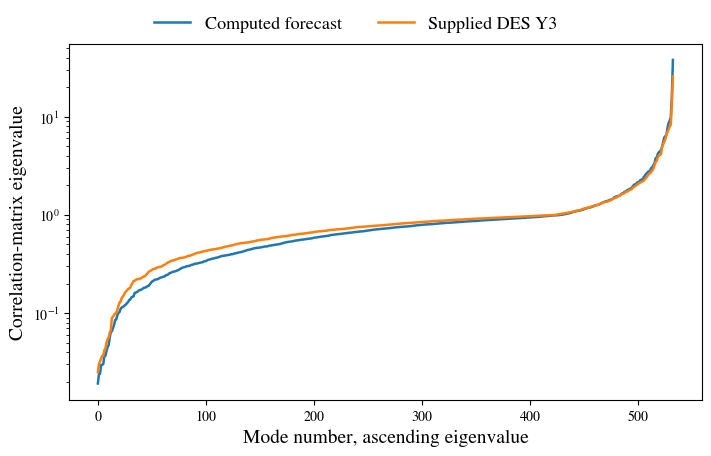

In [7]:
# Sorted correlation eigenvalues of both totals after the same cuts; the
# logarithmic axis shows the smallest modes, which an inverse amplifies most.
figure, axis = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for name, label in (("total", "Computed forecast"), ("supplied", "Supplied DES Y3")):
    modes = cov.covariance_modes(matrix=selected[name])
    correlation = modes["correlation_eigenvalues"]
    # Matplotlib takes the plotting coordinates as positional x, y arguments.
    axis.plot(np.arange(len(correlation)), correlation, label=label, linewidth=1.8)
axis.set_yscale("log")
axis.set_xlabel("Mode number, ascending eigenvalue", fontsize=14)
axis.set_ylabel("Correlation-matrix eigenvalue", fontsize=14)
figure.legend(loc="outside upper center", ncol=2, frameon=False, fontsize=13)
plt.show()

## Compare the selected entries with the supplied DES Y3 matrix

`select_likelihood_entries` reduced the 900-entry layout to the 533 entries the
DES Y3 likelihood keeps. The first cell checks that its supplied block equals
direct indexing of the file on both axes, then prints, per probe, the ratio of
standard deviations $\sqrt{C^{\rm forecast}_{ii}/C^{\rm DES}_{ii}}$; the probe labels
print in their LaTeX form. The second cell solves
$C^{\rm forecast}v=\lambda C^{\rm DES}v$: the smallest and largest $\lambda$ bound the
ratio of forecast to DES variance over every linear combination of the retained
measurements, so $\lambda=2$ means that some combination has twice the DES
variance in the forecast.

The two matrices rest on different physical inputs: the forecast has its own
fiducial cosmology, approximates the DES footprint by a spherical cap and makes
the simplifications listed at the top of this notebook. These numbers therefore
measure the difference between two models, not a numerical error. The supplied
matrix stays the covariance of the DES Y3 likelihoods.

In [8]:
# np.ix_(rows, columns) selects the submatrix at those rows and columns, so it
# applies the retained original positions to both axes of the supplied file.
retained = selected["indices"]
direct = supplied["total"][np.ix_(retained, retained)]
print("Retained", len(retained), "of", supplied["file_size"], "entries; equal to",
      "direct indexing:", np.array_equal(direct, selected["supplied"]))
sigma_ratio = np.sqrt(np.diag(selected["total"])/np.diag(selected["supplied"]))
start = 0
# zip pairs each probe label with its retained entry count, in vector order.
for label, count in zip(selected["block_labels"], selected["block_sizes"]):
    block = sigma_ratio[start:start+count]
    print(f"{label:12s} {count:4d} entries, sigma ratio median {np.median(block):.2f}, "
          f"range {block.min():.2f} to {block.max():.2f}")
    start += count

Retained 533 of 900 entries; equal to direct indexing: True
$\xi_+$       166 entries, sigma ratio median 0.99, range 0.94 to 1.23
$\xi_-$        61 entries, sigma ratio median 0.95, range 0.93 to 1.04
$\gamma_t$    252 entries, sigma ratio median 1.01, range 0.94 to 1.25
$w$            54 entries, sigma ratio median 1.07, range 0.89 to 1.52


In [9]:
# The generalized eigenvalues lambda of C_forecast v = lambda C_DES v bound the
# variance ratio (v^T C_forecast v)/(v^T C_DES v) over all combinations v.
versus_des = cov.compare_covariances(
    matrix=selected["total"], reference=selected["supplied"],
)
variance_ratio = versus_des["generalized_eigenvalues"]
print(f"Forecast/DES variance ratio: {variance_ratio[0]:.3f} to "
      f"{variance_ratio[-1]:.3f}, median {np.median(variance_ratio):.3f}")

Forecast/DES variance ratio: 0.415 to 2.425, median 0.887


## Other figures of `plot_covariances`

The shared plotting module `pcov` offers modes that the sections above do not use:

- `plot_covariance_components(..., normalization="element")` divides each component
  by the total entry by entry, $C^{\rm comp}_{ij}/C^{\rm total}_{ij}$, the
  normalization of Barreira, Krause & Schmidt (2018), Fig. 1; `percent=True`
  multiplies by 100. Where the total correlation is weak, the ratio divides two
  small numbers and would set the color scale, so `denominator_floor=0.05` leaves
  every entry with $|C_{ij}|\le0.05\sqrt{C_{ii}C_{jj}}$ grey and out of the
  histogram. That masking is display-only; the titles count the grey entries.
- `plot_correlation` without `covariance_ref` draws one matrix: here the full
  900-entry forecast before the mask, including the scales the likelihood
  removes. Without a reference only the first label, the title, is drawn.
- `plot_covariance_diagonal` without `covariance_ref` draws the standard
  deviations $\sqrt{C_{ii}}$ themselves: here those of the first two $\xi_+$ rows,
  source pairs (1,1) and (1,2), entries 0–39 before cuts, computed and supplied.

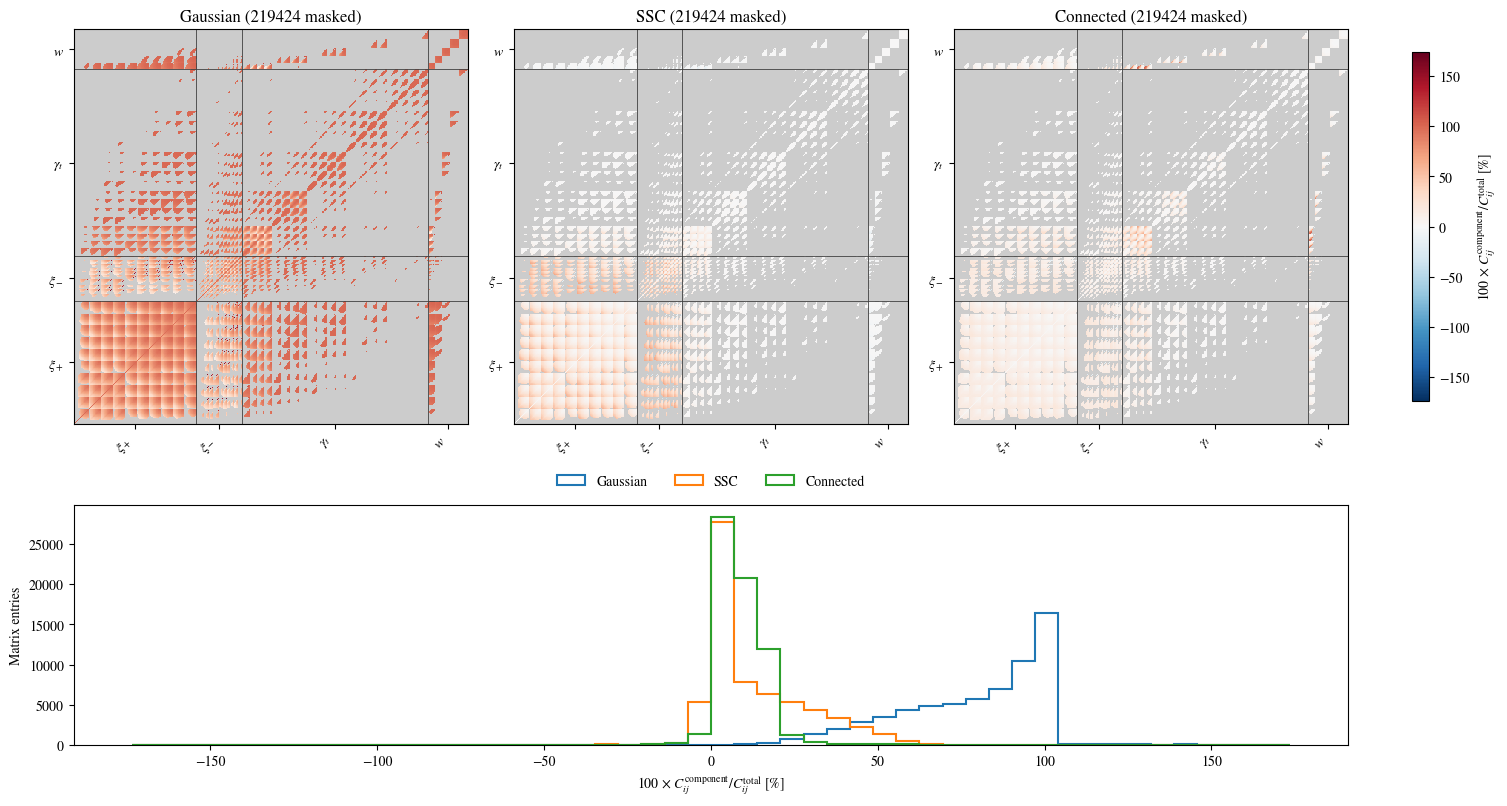

In [10]:
# Entries whose total correlation is at most 0.05 are grey (display-only):
# there the ratio of two small numbers would dominate the color scale.
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="element",
    denominator_floor=0.05,
    percent=True,
)

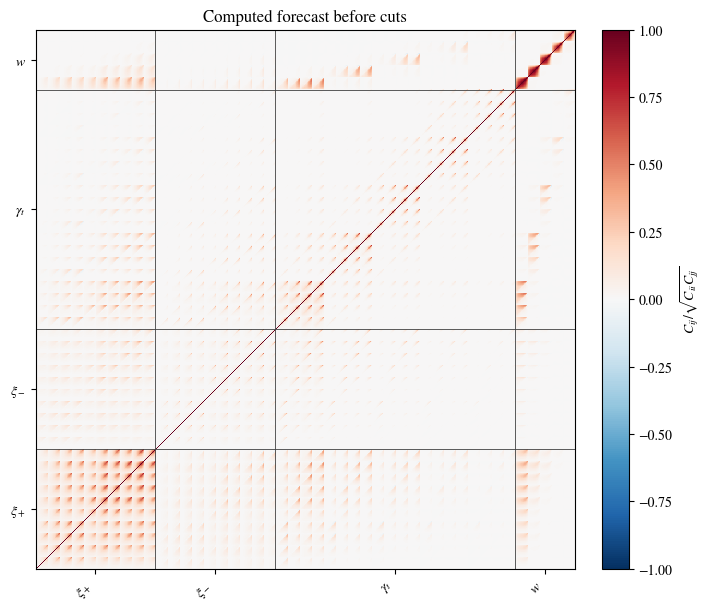

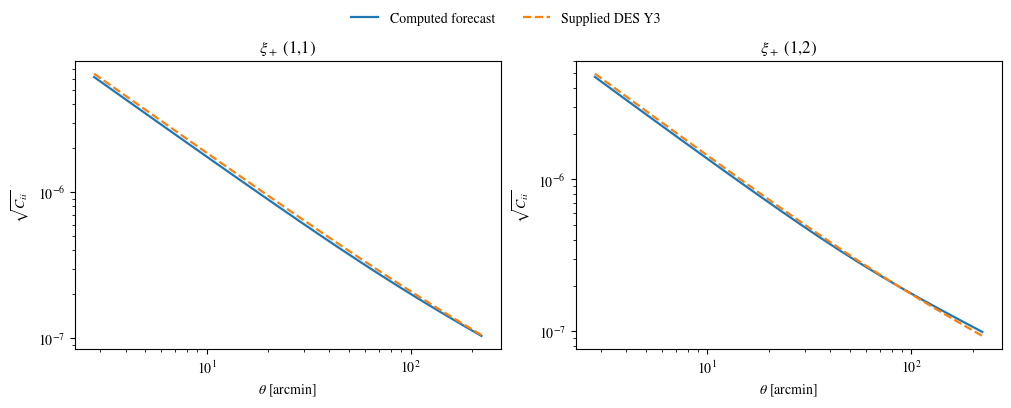

In [11]:
# One matrix, no reference: the full 900-entry forecast before the mask (the
# second label is not drawn), then sqrt(C_ii) of the first two xi_+ rows.
pcov.plot_correlation(
    covariance=forecast["total"], block_sizes=block_sizes,
    block_labels=block_labels, labels=("Computed forecast before cuts", ""),
)
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"],
    covariances={"Computed forecast": forecast["total"][:40, :40],
                 "Supplied DES Y3": supplied["total"][:40, :40]},
    panel_labels=["$\\xi_+$ (1,1)", "$\\xi_+$ (1,2)"],
)

## Check changes with accuracy boost

With two or more boosts, the next cell compares the *computed* matrices after
the same likelihood cuts. The highest tested boost is a comparison reference.
Generalized eigenvalues solve $C_bv=\lambda C_{\rm ref}v$, with $C_b$ the matrix at
boost $b$; they bound the variance ratio $v^{\mathsf T}C_bv/v^{\mathsf T}C_{\rm ref}v$
for every linear combination $v$ of retained measurements. The reported maximum
departure from one is a fraction; 0.01 means 1%.

The error-bar panel selects the first source auto-correlation, $\xi_+$ of the
source pair (1,1). It shows the percent change of $\sqrt{C_{ii}}$ relative to the
highest boost: diagonal entries only, which is why the generalized eigenvalues
are needed as well. Refine quadrature separately at fixed boost, and eventually
check marginalized Fisher errors and the Figure of Merit, the inverse area of a
two-parameter confidence region. No matrix here has its eigenvalues clipped or
its diagonal repaired.

The split-triangle layout follows [Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568).
Component maps adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).

In [12]:
if len(boosts) == 1:
    print("Set boosts = [1, 2] above and rerun to compare numerical accuracy.")
else:
    for boost in boosts:
        current = select_likelihood_entries(
            forecast=results[native_space][boost],
            supplied=supplied,
            block_sizes=block_sizes,
            block_labels=block_labels,
        )
        change = cov.compare_covariances(
            matrix=current["total"], reference=selected["total"],
        )
        print(boost, "maximum fractional variance change:",
              change["maximum_fractional_variance_change"])

    # The first observable is the first source auto-correlation, with
    # all its angular bins or Fourier bands consecutive in the full vector.
    nbin = 20
    reference = forecast["total"][:nbin, :nbin]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {boosts[-1]}"] = (
            results[native_space][boost]["total"][:nbin, :nbin]
        )
    coordinate = forecast["coordinate"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=coordinate,
        covariances=curves,
        panel_labels=['$\\xi_+$'],
        covariance_ref=reference,
        coordinate_label='$\\ell$' if native_space == "fourier" else '$\\theta\\;[\\mathrm{arcmin}]$',
    )

Set boosts = [1, 2] above and rerun to compare numerical accuracy.


## Inspect the C++ notebook interface

The compiled wrappers take vectors, matrices and cubes (three-dimensional
arrays) of Armadillo, the C++ linear-algebra library behind the notebook
interface, with named physical axes. Python converts NumPy inputs into owned
Armadillo arrays, copies that belong to the wrapper; notebook copies are
intentional. Whole Gaussian matrices and individual projection, halo and
response components are available for independent experiments. The help text
gives dimensions and units.

In [13]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)

Help on built-in function covariance_gaussian_fourier in module cosmolike_des_y3_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: object, noise: object, pairs: object, operators: object, ell_min: int, area_sr: float) -> Numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.
    
    Returns an owned symmetric [nobservable*nband,nobservable*nband] matrix,
    with bands in

## Save the calculation

The archives retain each physical component, ordering, physical assumptions and
resolved accuracy settings. The separate likelihood-selection archive contains
the compact matrices, original entry indices and the supplied total used in the
plot. Only files in `covariance/` are written; the supplied files in `data/`
remain unchanged. Running this cell again replaces the computed archives.

In [14]:
for space in spaces:
    save_forecast(
        result=results[space][boosts[-1]],
        filename=project/"covariance"/f"forecast_{space}.npz",
    )
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
np.savez(
    file=project/"covariance/forecast_likelihood_selection.npz",
    **selected,
    dataset=str(dataset.relative_to(project)),
    accuracy_boost=boosts[-1],
)
print("Saved covariance components and likelihood selection.")

Saved covariance components and likelihood selection.


## Reload the saved archives

`save_forecast` writes plain NumPy arrays and two JSON text fields, so the
archives load with `allow_pickle=False`. Pickle, Python's general object format,
can run code while loading, so a reader keeps it off. The next cell reloads each
saved forecast and the likelihood selection, checks that every matrix equals the
one still in memory, and reads the resolved accuracy boost back from
`settings_json`.

In [15]:
# allow_pickle=False refuses pickled objects, which save_forecast never writes;
# "with" closes each archive when its block ends.
import json
for space in spaces:
    filename = project/"covariance"/f"forecast_{space}.npz"
    with np.load(file=filename, allow_pickle=False) as archive:
        saved_settings = json.loads(str(archive["settings_json"]))
        for name in ("gaussian", "ssc", "cng", "total"):
            identical = np.array_equal(archive[name], results[space][boosts[-1]][name])
            print(f"{filename.name}: {name} identical after reload: {identical}")
        print(f"{filename.name}: accuracy_boost {saved_settings['accuracy_boost']}")
selection_file = project/"covariance/forecast_likelihood_selection.npz"
with np.load(file=selection_file, allow_pickle=False) as archive:
    identical = np.array_equal(archive["total"], selected["total"])
    print(f"{selection_file.name}: total identical after reload: {identical}")

forecast_real.npz: gaussian identical after reload: True
forecast_real.npz: ssc identical after reload: True
forecast_real.npz: cng identical after reload: True
forecast_real.npz: total identical after reload: True
forecast_real.npz: accuracy_boost 1
forecast_likelihood_selection.npz: total identical after reload: True
